# Chapter 3 — Floating-point arithmetic

**Numerical Linear Algebra: Theory, Algorithms, and Computation**

**Abdallah Alsammani, Ph.D.**  
Department of Mathematical Sciences & Data Science  
Delaware State University

Lecture notes: <https://aalsammani.github.io/numerical-linear-algebra/>  
Notes for this chapter: <https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html>  
Repository: <https://github.com/aalsammani/Numerical-Linear-Algebra-Notebooks>

This notebook is the computational laboratory of the chapter; the theory,
proofs and exercises are in the lecture notes, to which the links below
point. References such as Trefethen and Bau (1997) are listed in the
[bibliography of the notes](https://aalsammani.github.io/numerical-linear-algebra/back/bibliography.html). Version
1.0, September 2026.

---

This notebook accompanies [Chapter 3](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03) of the notes. Every
experiment checks a statement of the chapter, and wherever possible it
measures errors *exactly*, with rational arithmetic from the `fractions`
module or with high-precision decimals, instead of comparing one
floating-point result with another.

**Learning objectives.** After working through this lab you should be able to

1. decode the sign, exponent and fraction bits of a binary64 number and
   explain the hidden bit and subnormal numbers;
2. use `np.spacing`, `np.nextafter` and `np.finfo` to explore the spacing of
   floating-point numbers, and explain the difference between the unit
   roundoff $u = 2^{-53}$ and machine epsilon $\epsilon_{\mathrm{mach}} = 2^{-52}$;
3. verify the bound $\operatorname{fl}(x) = x(1+\delta)$, $|\delta|\le u$ with exact
   arithmetic and exhibit its failure in the subnormal range;
4. implement recursive, pairwise and compensated summation and test them
   against the error bounds of the chapter on well- and ill-conditioned sums;
5. recognize and repair cancellation, overflow and underflow.

Run the cells in order from a fresh kernel.

In [1]:
import math
import struct
import sys
from decimal import Decimal, localcontext, ROUND_HALF_EVEN
from fractions import Fraction

import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.linalg as sla

rng = np.random.default_rng(20260927)
u = 2.0**-53                          # unit roundoff of binary64
eps = np.finfo(float).eps             # machine epsilon of binary64, 2**-52
u32 = 2.0**-24                        # unit roundoff of binary32
assert eps == 2 * u and np.finfo(np.float32).eps == 2 * u32


def gamma(n, unit=u):
    """gamma_n = n u / (1 - n u), defined for n u < 1."""
    assert n * unit < 1
    return n * unit / (1 - n * unit)


plt.rcParams.update({"figure.figsize": (6.4, 4.0), "axes.grid": True, "grid.alpha": 0.3})
print(f"Python {sys.version.split()[0]}, NumPy {np.__version__}, SciPy {scipy.__version__}")
print(f"u = 2^-53 = {u:.4e},  eps_mach = np.finfo(float).eps = {eps:.4e}")

Python 3.14.3, NumPy 2.5.3, SciPy 1.18.1
u = 2^-53 = 1.1102e-16,  eps_mach = np.finfo(float).eps = 2.2204e-16


## 1. Anatomy of a binary64 number

A binary64 number is stored in 64 bits: one sign bit, an 11-bit biased
exponent field $E$ and a 52-bit fraction field $f$. For $1\le E\le 2046$ the
value is $(-1)^s\,(1.f)_2\times 2^{E-1023}$: the leading $1$ is the *hidden
bit*, which is not stored. So binary64 has 52 stored fraction bits and 53 bits
of precision. The field $E = 0$ encodes zero and the subnormal numbers
$(-1)^s(0.f)_2\times2^{-1022}$, and $E = 2047$ encodes infinities and NaNs.
The function below extracts the three fields with `struct` and reconstructs
the value from them.

In [2]:
def fields(x):
    """Return (sign, biased exponent E, fraction f as an integer) of a binary64 number."""
    (bits,) = struct.unpack(">Q", struct.pack(">d", x))
    return bits >> 63, (bits >> 52) & 0x7FF, bits & ((1 << 52) - 1)


def value_from_fields(s, E, f):
    """Exact value (as a Fraction) of a finite binary64 number with the given fields."""
    if E == 0:                                   # zero or subnormal: no hidden bit
        mag = Fraction(f, 2**52) * Fraction(2) ** -1022
    else:                                        # normalized: hidden bit 1
        mag = (1 + Fraction(f, 2**52)) * Fraction(2) ** (E - 1023)
    return -mag if s else mag


print(f"{'x':>24s}  s     E   e=E-1023  fraction (52 bits, hex)")
for x in [1.0, 0.1, -2.5, 2.0**-1074, float(np.finfo(float).tiny), float(np.finfo(float).max), math.inf, math.nan]:
    s, E, f = fields(x)
    print(f"{x!r:>24s}  {s}  {E:4d}  {E - 1023:8d}  {f:013x}")
    if E != 2047:
        assert value_from_fields(s, E, f) == Fraction(x)   # exact reconstruction

                       x  s     E   e=E-1023  fraction (52 bits, hex)
                     1.0  0  1023         0  0000000000000
                     0.1  0  1019        -4  999999999999a
                    -2.5  1  1024         1  4000000000000
                  5e-324  0     0     -1023  0000000000001
 2.2250738585072014e-308  0     1     -1022  0000000000000
 1.7976931348623157e+308  0  2046      1023  fffffffffffff
                     inf  0  2047      1024  0000000000000
                     nan  0  2047      1024  8000000000000


The fraction of $0.1$ is `999999999999a`: the repeating binary pattern
$1001\,1001\ldots$ has been rounded *up* in its last place, as in
[Example 3.2](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-exa-one-tenth). The smallest subnormal number $2^{-1074}$ has
$E = 0$ and fraction $1$. `np.frexp` gives another normalization,
$x = m\cdot2^k$ with $0.5\le|m|<1$, which differs from the IEEE convention
by one in the exponent.

In [3]:
m, k = np.frexp(0.1)
print(f"np.frexp(0.1) = ({m!r}, {k});  IEEE exponent e = {fields(0.1)[1] - 1023}")
print("stored value of 0.1 :", Decimal(0.1))
rel = (Fraction(0.1) - Fraction(1, 10)) / Fraction(1, 10)
print("relative error of fl(0.1) =", rel, "= 2^-54:", rel == Fraction(1, 2**54))
print("0.1 + 0.2 =", repr(0.1 + 0.2), "  equal to 0.3?", 0.1 + 0.2 == 0.3)

np.frexp(0.1) = (np.float64(0.8), -3);  IEEE exponent e = -4
stored value of 0.1 : 0.1000000000000000055511151231257827021181583404541015625
relative error of fl(0.1) = 1/18014398509481984 = 2^-54: True
0.1 + 0.2 = 0.30000000000000004   equal to 0.3? False


The precision is 53 bits, so every integer up to $2^{53}$ is a binary64
number, but $2^{53}+1$ is not: it lies halfway between $2^{53}$ and
$2^{53}+2$ and rounds to the even neighbor $2^{53}$.

In [4]:
print("float(2**53 + 1) == 2**53:", float(2**53 + 1) == 2.0**53)
assert float(2**53 + 1) == 2.0**53 and float(2**53 - 1) == 2**53 - 1

float(2**53 + 1) == 2**53: True


`np.finfo` reports the parameters of each format. `nmant` is the number of
*stored* fraction bits, so the precision is `nmant + 1`. (NumPy's `maxexp` is
$e_{\max}+1$.) NumPy has no bfloat16 type; its parameters are $p = 8$,
$e_{\min} = -126$, $e_{\max} = 127$.

In [5]:
print(f"{'format':>8s} {'p':>3s} {'u = 2^-p':>10s} {'eps_mach':>10s} {'x_min':>10s} {'min subnormal':>14s} {'x_max':>10s}")
for t in (np.float16, np.float32, np.float64):
    fi = np.finfo(t)
    p = fi.nmant + 1
    print(f"{t.__name__:>8s} {p:3d} {2.0**-p:10.3e} {float(fi.eps):10.3e} {float(fi.tiny):10.3e} "
          f"{float(fi.smallest_subnormal):14.3e} {float(fi.max):10.3e}")
    assert float(fi.eps) == 2.0 ** (1 - p)                          # eps_mach = 2 u
    assert float(fi.max) == (2 - 2.0 ** (1 - p)) * 2.0 ** (fi.maxexp - 1)
bf16_max = (2 - 2.0**-7) * 2.0**127
print(f"{'bfloat16':>8s} {8:3d} {2.0**-8:10.3e} {2.0**-7:10.3e} {2.0**-126:10.3e} {2.0**-133:14.3e} {bf16_max:10.3e}")

  format   p   u = 2^-p   eps_mach      x_min  min subnormal      x_max
 float16  11  4.883e-04  9.766e-04  6.104e-05      5.960e-08  6.550e+04
 float32  24  5.960e-08  1.192e-07  1.175e-38      1.401e-45  3.403e+38
 float64  53  1.110e-16  2.220e-16 2.225e-308     4.941e-324 1.798e+308
bfloat16   8  3.906e-03  7.812e-03  1.175e-38      9.184e-41  3.390e+38


## 2. Spacing of floating-point numbers and machine epsilon

In the binade $[2^e, 2^{e+1})$ binary64 numbers are spaced
$\operatorname{ulp} = 2^{e-52}$ apart, so the relative spacing
$\operatorname{ulp}(x)/|x|$ lies in $(u, 2u]$ (equation [(3.3)](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#equation-ch03-eq-relative-spacing)).
We check this for numbers spread over the whole normal range.

In [6]:
x = np.exp(rng.uniform(np.log(1e-300), np.log(1e300), 100_000))
rel_spacing = np.spacing(x) / x
print(f"relative spacing / u:  min {rel_spacing.min() / u:.6f},  max {rel_spacing.max() / u:.6f}")
assert np.all(rel_spacing > u) and np.all(rel_spacing <= 2 * u)

print("neighbors of 1:", repr(np.nextafter(1.0, 0.0)), repr(np.nextafter(1.0, 2.0)))
assert np.nextafter(1.0, 0.0) == 1 - u and np.nextafter(1.0, 2.0) == 1 + eps
assert np.spacing(1.0) == eps

relative spacing / u:  min 1.000006,  max 1.999999
neighbors of 1: np.float64(0.9999999999999999) np.float64(1.0000000000000002)


At a power of two the gap below is half the gap above. Now the facts of
[Proposition 3.1](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-prop-smallest-eps). The number $1+2^{-53}$ is exactly halfway
between $1$ and $1+2^{-52}$, and round to nearest *ties to even* chooses $1$,
whose last significand bit is $0$.

In [7]:
print("1 + 2**-53 > 1 :", 1 + 2**-53 > 1)
print("1 + 2**-52 > 1 :", 1 + 2**-52 > 1)
e_small = np.nextafter(2.0**-53, 1.0)             # the next float after 2^-53
print("next float after 2^-53 equals 2^-53 + 2^-105:", e_small == 2.0**-53 + 2.0**-105)
print("1 + (2^-53 + 2^-105) == 1 + 2^-52:", 1 + e_small == 1 + eps)
assert (1 + 2**-53 == 1) and (1 + e_small == 1 + eps)

# Ties to even can also round up: 1 + 2^-52 has an odd last bit.
print("(1 + 2^-52) + 2^-53 == 1 + 2^-51:", (1 + eps) + u == 1 + 2 * eps)
# Addition is not associative.
print("(1 + u) + u =", repr((1 + u) + u), "   1 + (u + u) =", repr(1 + (u + u)))
assert (1 + u) + u == 1 and 1 + (u + u) == 1 + eps

1 + 2**-53 > 1 : False
1 + 2**-52 > 1 : True
next float after 2^-53 equals 2^-53 + 2^-105: True
1 + (2^-53 + 2^-105) == 1 + 2^-52: True
(1 + 2^-52) + 2^-53 == 1 + 2^-51: True
(1 + u) + u = 1.0    1 + (u + u) = 1.0000000000000002


The legacy version of this course computed machine epsilon with the loop
below and claimed that it finds "the smallest $\epsilon$ with
$\operatorname{fl}(1+\epsilon)>1$." The loop does return $2^{-52}$, but only because it
tests powers of two; the smallest floating-point $\epsilon$ with that
property is $2^{-53}+2^{-105}$, which is not a power of two.

In [8]:
eps_loop = 1.0
while 1.0 + eps_loop / 2 > 1.0:
    eps_loop /= 2
print("halving loop returns", eps_loop, "= 2^-52:", eps_loop == 2.0**-52)
assert eps_loop == eps

halving loop returns 2.220446049250313e-16 = 2^-52: True


Two conventions are in use: this book (like Higham, and like
Trefethen and Bau's $\epsilon_{\text{machine}}$) bounds the relative
rounding error by $u = 2^{-53}$, while `np.finfo(float).eps`, MATLAB's `eps`
and C's `DBL_EPSILON` are $\epsilon_{\mathrm{mach}} = 2u = 2^{-52}$.

## 3. Rounding errors measured exactly

[Theorem 3.1](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-thm-rounding) says that for $x$ in the normal range,
$\operatorname{fl}(x) = x(1+\delta)$ with $|\delta|\le u$. Python's `float(Fraction)`
divides two integers with correct rounding, so we can generate random
rational numbers $q$ of many magnitudes, round them, check that the result
is really the nearest float (by comparing with both neighbors), and compute
$\delta$ exactly.

max |delta| / u = 0.994410


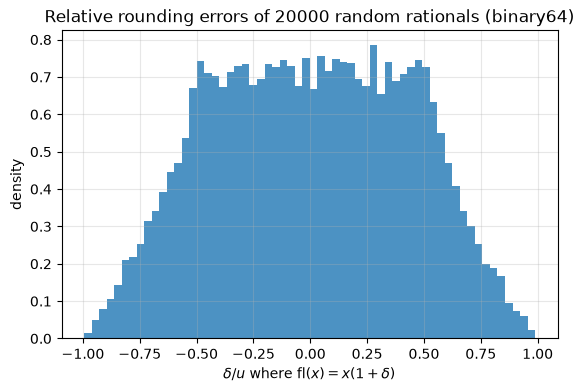

In [9]:
def rel_err_exact(computed, exact):
    """Exact relative error (as a float) of a float against a Fraction."""
    return float((Fraction(computed) - exact) / exact)


deltas = []
for _ in range(20_000):
    q = Fraction(int(rng.integers(1, 2**62)), int(rng.integers(1, 2**62))) * Fraction(2) ** int(rng.integers(-950, 950))
    f = float(q)
    lo, hi = np.nextafter(f, 0.0), np.nextafter(f, math.inf)
    assert abs(Fraction(f) - q) <= abs(Fraction(lo) - q) and abs(Fraction(f) - q) <= abs(Fraction(hi) - q)
    deltas.append(rel_err_exact(f, q))
deltas = np.array(deltas)
print(f"max |delta| / u = {np.max(np.abs(deltas)) / u:.6f}")
assert np.max(np.abs(deltas)) <= u      # Theorem: |delta| <= u in the normal range

fig, ax = plt.subplots()
ax.hist(deltas / u, bins=60, density=True, alpha=0.8)
ax.set_xlabel(r"$\delta / u$ where $\mathrm{fl}(x) = x(1+\delta)$")
ax.set_ylabel("density")
ax.set_title("Relative rounding errors of 20000 random rationals (binary64)")
plt.show()

The errors fill $[-u, u]$ and never leave it. The density is not uniform:
relative errors near $\pm u$ occur only for numbers just above a power of
two, where the relative spacing is largest (the sawtooth of
[Figure 3.1](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-fig-number-system)).

**The standard model.** For floating-point operands, IEEE 754 requires the
result of $+,-,\times,\div$ to be the correctly rounded exact result. We
check $|\delta|\le u$ for each operation with exact rational arithmetic, and
for the square root we check correct rounding directly: $x$ must lie between
the squares of the midpoints of $r = \operatorname{fl}(\sqrt x)$ and its two neighbors.

In [10]:
def random_floats(size):
    return rng.standard_normal(size) * 10.0 ** rng.integers(-100, 100, size)


X, Y = random_floats(5000), random_floats(5000)
worst = {}
for name, op in [("+", np.add), ("-", np.subtract), ("*", np.multiply), ("/", np.divide)]:
    exact_op = {"+": lambda a, b: a + b, "-": lambda a, b: a - b,
                "*": lambda a, b: a * b, "/": lambda a, b: a / b}[name]
    errs = [abs(rel_err_exact(op(x, y), exact_op(Fraction(x), Fraction(y)))) for x, y in zip(X, Y)]
    worst[name] = max(errs) / u
    assert max(errs) <= u
for x in np.abs(X[:2000]):
    r = math.sqrt(x)
    mid_lo = (Fraction(r) + Fraction(np.nextafter(r, 0.0))) / 2
    mid_hi = (Fraction(r) + Fraction(np.nextafter(r, math.inf))) / 2
    assert mid_lo**2 <= Fraction(x) <= mid_hi**2     # r is the nearest float to sqrt(x)
print("max |delta|/u per operation:", {k: round(v, 4) for k, v in worst.items()}, "; sqrt correctly rounded")

max |delta|/u per operation: {'+': 0.968, '-': 0.9776, '*': 0.9965, '/': 0.9957} ; sqrt correctly rounded


**Failure in the subnormal range.** Below $x_{\min} = 2^{-1022}$ the numbers
are spaced $2^{-1074}$ apart, so the *absolute* error of rounding is at most
$2^{-1075}$ ([Theorem 3.2](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-thm-underflow)) but the *relative* error can be
large.

In [11]:
for q in [3 * Fraction(2) ** -1076, Fraction(2) ** -1075, Fraction(7, 10) * Fraction(2) ** -1070]:
    f = float(q)
    print(f"x = {float(q * 2**1074):.4f} * 2^-1074 -> fl(x) = {f!r:>10s}, relative error {abs(rel_err_exact(f, q)):.4f}")
assert float(3 * Fraction(2) ** -1076) == 2.0**-1074 and float(Fraction(2) ** -1075) == 0.0

tiny_q = [Fraction(int(rng.integers(1, 2**60)), 2**60) * Fraction(2) ** -1022 for _ in range(2000)]
abs_errs = [abs(Fraction(float(q)) - q) for q in tiny_q]
assert max(abs_errs) <= Fraction(2) ** -1075        # |eta| <= 2^(e_min - p)
print("max absolute error in the subnormal range / 2^-1075 =", float(max(abs_errs) / Fraction(2) ** -1075))

x = 0.7500 * 2^-1074 -> fl(x) =     5e-324, relative error 0.3333
x = 0.5000 * 2^-1074 -> fl(x) =        0.0, relative error 1.0000
x = 11.2000 * 2^-1074 -> fl(x) =   5.4e-323, relative error 0.0179
max absolute error in the subnormal range / 2^-1075 = 1.0


## 4. Special values

Overflow happens when the exact result reaches $x_{\max}$ plus half an ulp:
$x_{\max} + 2^{970}$ is a tie between $x_{\max}$ (odd last bit) and
$2^{1024}$ and becomes `inf`, while $x_{\max}+2^{969}$ rounds back to
$x_{\max}$. NumPy signals exceptions as warnings, which we silence
explicitly with `np.errstate`; plain Python floats raise an exception on
division by zero.

In [12]:
xmax = np.finfo(float).max
with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
    print("xmax + 2^970 =", np.float64(xmax) + 2.0**970, "   xmax + 2^969 =", np.float64(xmax) + 2.0**969)
    assert np.isinf(np.float64(xmax) + 2.0**970) and np.float64(xmax) + 2.0**969 == xmax
    one, zero, inf = np.float64(1.0), np.float64(0.0), np.float64(np.inf)
    print("1/+0 =", one / zero, "  1/-0 =", one / -zero, "  inf - inf =", inf - inf,
          "  0 * inf =", zero * inf, "  0/0 =", zero / zero)
nan = float("nan")
print("nan == nan:", nan == nan, "  nan != nan:", nan != nan, "  +0 == -0:", 0.0 == -0.0,
      "  copysign(1, -0.0) =", math.copysign(1, -0.0))
try:
    1.0 / 0.0
except ZeroDivisionError as err:
    print("plain Python:", type(err).__name__, "-", err)

xmax + 2^970 = inf    xmax + 2^969 = 1.7976931348623157e+308
1/+0 = inf   1/-0 = -inf   inf - inf = nan   0 * inf = nan   0/0 = nan
nan == nan: False   nan != nan: True   +0 == -0: True   copysign(1, -0.0) = -1.0
plain Python: ZeroDivisionError - division by zero


**Gradual underflow.** [Lemma 3.1](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-lem-subnormal-exact) says that sums
and differences smaller than $2x_{\min}$ in magnitude are exact. In
particular $x\ne y$ implies $\operatorname{fl}(x-y)\ne0$.

In [13]:
xmin = np.finfo(float).tiny
a = xmin * (1 + rng.integers(0, 2**20, 5000) * eps)        # floats just above x_min
b = np.nextafter(a, 0.0)                                    # their lower neighbors
d = a - b
assert np.all(d != 0) and np.all(d == 2.0**-1074)          # exact: the gap is one subnormal step
c = rng.uniform(-2, 2, 5000) * xmin
e = rng.uniform(-2, 2, 5000) * xmin
small = np.abs(c + e) < 2 * xmin
assert all(Fraction(float(s)) == Fraction(float(p)) + Fraction(float(q))
           for s, p, q in zip((c + e)[small], c[small], e[small]))
print(f"{small.sum()} sums below 2 x_min checked: all exact; all differences of neighbors are 2^-1074")

3767 sums below 2 x_min checked: all exact; all differences of neighbors are 2^-1074


## 5. The $\gamma_n$ lemma

[Lemma 3.3](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-lem-gamma) bounds $\prod_{i=1}^n(1+\delta_i)^{\pm1} - 1$ by
$\gamma_n = nu/(1-nu)$. The worst case is $\delta_i = -u$ with exponent $-1$
for all $i$, which gives exactly $(1-u)^{-n}-1$. We compute these products
exactly and compare with $\gamma_n$.

In [14]:
U = Fraction(1, 2**53)
for n in (1, 10, 100, 1000):
    worst_case = (1 - U) ** -n - 1                # delta_i = -u, all exponents -1
    print(f"n = {n:4d}: (1-u)^-n - 1 = {float(worst_case):.6e},  gamma_n = {gamma(n):.6e},  "
          f"ratio {float(worst_case) / gamma(n):.12f}")
    assert worst_case <= n * U / (1 - n * U)
# random signs and exponents
for trial in range(200):
    n = int(rng.integers(1, 60))
    th = Fraction(1)
    for _ in range(n):
        delta = Fraction(int(rng.integers(-2**20, 2**20)), 2**20) * U
        th *= (1 + delta) if rng.random() < 0.5 else 1 / (1 + delta)
    assert abs(th - 1) <= n * U / (1 - n * U)
print("200 random products satisfy |theta_n| <= gamma_n")

n =    1: (1-u)^-n - 1 = 1.110223e-16,  gamma_n = 1.110223e-16,  ratio 1.000000000000
n =   10: (1-u)^-n - 1 = 1.110223e-15,  gamma_n = 1.110223e-15,  ratio 1.000000000000
n =  100: (1-u)^-n - 1 = 1.110223e-14,  gamma_n = 1.110223e-14,  ratio 1.000000000000
n = 1000: (1-u)^-n - 1 = 1.110223e-13,  gamma_n = 1.110223e-13,  ratio 1.000000000000
200 random products satisfy |theta_n| <= gamma_n


The ratio of the worst case to $\gamma_n$ is $1$ to many digits: the lemma
is sharp to first order, and $\gamma_n\approx nu$ whenever $nu\ll1$.

## 6. Summation

We implement the three algorithms of [Section 3.5](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-sec-summation). Python's
built-in `sum` is *not* used for recursive summation: since Python 3.12 it
uses a more accurate compensated algorithm for floats. The exact reference
is `math.fsum`, which returns the correctly rounded exact sum; we first
confirm this against rational arithmetic.

In [15]:
def recursive_sum(x):
    s = 0.0
    for xi in x:
        s += xi
    return s


def pairwise_sum(x):
    n = len(x)
    if n == 1:
        return x[0]
    m = n // 2
    return pairwise_sum(x[:m]) + pairwise_sum(x[m:])


def kahan_sum(x):
    s, c = 0.0, 0.0
    for xi in x:
        y = xi - c
        t = s + y
        c = (t - s) - y            # rounding error of t (exact when |s| >= |y|)
        s = t
    return s


def exact_sum(x):
    return sum((Fraction(v) for v in x), Fraction(0))


for trial in range(20):
    x = list(rng.standard_normal(500) * 10.0 ** rng.integers(-8, 8, 500))
    assert math.fsum(x) == float(exact_sum(x))
print("math.fsum agrees with the correctly rounded exact sum in 20 tests")

math.fsum agrees with the correctly rounded exact sum in 20 tests


**Worked example** ([Example 3.3](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-exa-ordering)). For $x = (1,u,u,u,u)$ the
order of summation decides whether the result is exact.

In [16]:
x = [1.0] + [u] * 4
fwd, bwd = recursive_sum(x), recursive_sum(x[::-1])
print(f"forward: {fwd!r}   backward: {bwd!r}   exact: 1 + 4u = {1 + 4 * u!r}")
err = exact_sum(x) - Fraction(fwd)
bound = gamma(4) * math.fsum(abs(v) for v in x)
print(f"forward error = {float(err / U):.1f} u,  bound gamma_4 * sum|x_i| = {bound / u:.10f} u")
assert fwd == 1.0 and bwd == 1 + 4 * u and float(err) <= bound

forward: 1.0   backward: 1.0000000000000004   exact: 1 + 4u = 1.0000000000000004
forward error = 4.0 u,  bound gamma_4 * sum|x_i| = 4.0000000000 u


**An ill-conditioned sum.** For $x = (10^{16}, 1, -10^{16})$ the condition
number is $\kappa_\Sigma = 2\times10^{16}+1$. Recursive *and* compensated
summation both return $0$ instead of $1$: the compensation cannot recover a
digit that the first addition has already rounded away, exactly as the bound
$(2u + O(nu^2))\kappa_\Sigma$ allows.

In [17]:
x = [1e16, 1.0, -1e16]
print("recursive:", recursive_sum(x), "  pairwise:", pairwise_sum(x), "  Kahan:", kahan_sum(x),
      "  math.fsum:", math.fsum(x))
print(f"Python {sys.version.split()[0]} built-in sum: {sum(x)}  (compensated since Python 3.12)")
assert recursive_sum(x) == 0.0 and kahan_sum(x) == 0.0 and math.fsum(x) == 1.0

recursive: 0.0   pairwise: 0.0   Kahan: 0.0   math.fsum: 1.0
Python 3.14.3 built-in sum: 1.0  (compensated since Python 3.12)


**Experiment: error against $n$.** To see the growth with $n$ at moderate
sizes we work in binary32, where $u = 2^{-24}\approx5.96\times10^{-8}$, with
positive terms uniformly distributed in $[0,1)$ ($\kappa_\Sigma = 1$). NumPy's
binary32 random numbers are multiples of $2^{-24}$, so the exact sums are
integers times $2^{-24}$ and can be computed exactly in 64-bit integer
arithmetic. `np.cumsum` adds sequentially, which is recursive summation; the
Kahan and pairwise versions below are vectorized over several independent
sequences.

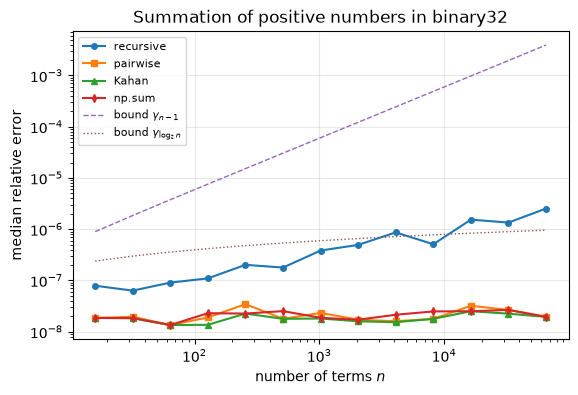

median relative errors at n = 2^16: {'recursive': '2.5e-06', 'pairwise': '1.9e-08', 'Kahan': '1.9e-08', 'np.sum': '1.9e-08'}


In [18]:
def kahan_rows(X):
    """Kahan summation of each row of X in the precision of X."""
    s = np.zeros(X.shape[0], dtype=X.dtype)
    c = np.zeros(X.shape[0], dtype=X.dtype)
    for i in range(X.shape[1]):
        y = X[:, i] - c
        t = s + y
        c = (t - s) - y
        s = t
    return s


def pairwise_rows(X):
    """Pairwise summation of each row; the row length must be a power of 2."""
    while X.shape[1] > 1:
        X = X[:, 0::2] + X[:, 1::2]
    return X[:, 0]


trials, ks = 8, np.arange(4, 17)
X32 = rng.random((trials, 2 ** ks[-1]), dtype=np.float32)
ints = (X32.astype(np.float64) * 2**24).astype(np.int64)
res = {"recursive": [], "pairwise": [], "Kahan": [], "np.sum": []}
for k in ks:
    n = 2**k
    exact = ints[:, :n].sum(axis=1) * 2.0**-24                 # exact (fits in 53 bits)
    comp = {"recursive": np.cumsum(X32[:, :n], axis=1)[:, -1],
            "pairwise": pairwise_rows(X32[:, :n]),
            "Kahan": kahan_rows(X32[:, :n]),
            "np.sum": X32[:, :n].sum(axis=1)}
    for name, val in comp.items():
        rel = np.abs(val.astype(np.float64) - exact) / exact
        res[name].append(np.median(rel))
        if name == "recursive":
            assert np.all(rel <= gamma(n - 1, u32))              # recursive summation bound, kappa = 1
        if name == "pairwise":
            assert np.all(rel <= gamma(k, u32))                  # bound gamma_{log2 n}
        if name == "Kahan":
            assert np.all(rel <= 3 * u32)                        # 2u + O(n u^2); n u^2 < 0.01 u here
ns = 2**ks
fig, ax = plt.subplots()
for name, mk in zip(res, "os^d"):
    ax.loglog(ns, np.maximum(res[name], 1e-10), mk + "-", ms=4, label=name)
ax.loglog(ns, [gamma(n - 1, u32) for n in ns], "--", lw=1, label=r"bound $\gamma_{n-1}$")
ax.loglog(ns, [gamma(k, u32) for k in ks], ":", lw=1, label=r"bound $\gamma_{\log_2 n}$")
ax.set_xlabel("number of terms $n$")
ax.set_ylabel("median relative error")
ax.set_title("Summation of positive numbers in binary32")
ax.legend(fontsize=8)
plt.show()
print("median relative errors at n = 2^16:", {k: f"{v[-1]:.1e}" for k, v in res.items()})

**Interpretation.** All bounds hold. Recursive summation has the largest
errors, growing with $n$ but staying well below the worst-case bound
$\gamma_{n-1}$; pairwise and Kahan summation stay at the level of $u$.
`np.sum` uses a blocked ("partial") pairwise scheme and behaves like pairwise
summation here.

**Experiment: error against the condition number.** Now we fix $n = 1000$
in binary64 and vary the amount of cancellation: half of the terms are
$a_i + c_i$ and half are $-a_i$, in random order, and the size of the $c_i$
controls $\kappa_\Sigma = \sum|x_i|/|\sum x_i|$. The reference is `math.fsum`.

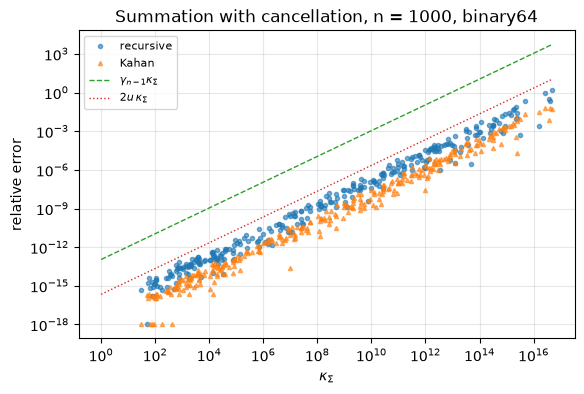

In [19]:
n = 1000
kap, e_rec, e_kah = [], [], []
for _ in range(300):
    t = 10.0 ** rng.uniform(-14, 0)
    a_ = rng.standard_normal(n // 2)
    x = rng.permutation(np.concatenate([a_ + t * rng.standard_normal(n // 2), -a_])).tolist()
    s = math.fsum(x)
    kappa = math.fsum(abs(v) for v in x) / abs(s)
    r_rec = abs(recursive_sum(x) - s) / abs(s)
    r_kah = abs(kahan_sum(x) - s) / abs(s)
    # Bounds gamma_{n-1} kappa and (2u + O(n u^2)) kappa, plus the rounding (at most u) of the
    # correctly rounded reference; the factor 1 + 4u covers the rounding in the computed kappa.
    assert r_rec <= (gamma(n - 1) * kappa + u) * (1 + 4 * u)
    assert r_kah <= (3 * u * kappa + u) * (1 + 4 * u)
    kap.append(kappa); e_rec.append(r_rec); e_kah.append(r_kah)
kap = np.array(kap)
fig, ax = plt.subplots()
ax.loglog(kap, np.maximum(e_rec, 1e-18), "o", ms=3, alpha=0.6, label="recursive")
ax.loglog(kap, np.maximum(e_kah, 1e-18), "^", ms=3, alpha=0.6, label="Kahan")
kk = np.logspace(0, np.log10(kap.max()), 50)
ax.loglog(kk, gamma(n - 1) * kk, "--", lw=1, label=r"$\gamma_{n-1}\kappa_\Sigma$")
ax.loglog(kk, 2 * u * kk, ":", lw=1, label=r"$2u\,\kappa_\Sigma$")
ax.set_xlabel(r"$\kappa_\Sigma$")
ax.set_ylabel("relative error")
ax.set_title("Summation with cancellation, n = 1000, binary64")
ax.legend(fontsize=8)
plt.show()

The relative error of both methods grows in proportion to $\kappa_\Sigma$.
Compensated summation reduces the backward error from about $(n-1)u$ to
about $2u$, but it cannot make an ill-conditioned sum well conditioned. (The
points at relative error $10^{-18}$ are sums computed exactly.)

**The running error bound.** [Proposition 3.2](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-prop-running-bound) gives the
a-posteriori bound $|\widehat s_n - s_n|\le u\sum_{i\ge2}|\widehat s_i|$, which
depends on the partial sums and hence on the ordering.

In [20]:
x = (rng.random(2000) * 10.0 ** rng.integers(0, 6, 2000)).tolist()
for order, xs in [("given", x), ("increasing", sorted(x)), ("decreasing", sorted(x, reverse=True))]:
    partial = np.cumsum(xs)                     # np.cumsum adds sequentially: the computed partial sums
    err = abs(Fraction(float(partial[-1])) - exact_sum(xs))
    running = u * math.fsum(abs(v) for v in partial[1:])
    assert float(err) <= running * (1 + 2 * u)     # exact bound; the factor covers the rounding of fsum
    print(f"{order:>10s} order: error = {float(err):.3e},  running bound = {running:.3e}")

     given order: error = 2.058e-08,  running bound = 2.045e-06
increasing order: error = 1.295e-08,  running bound = 2.951e-07
decreasing order: error = 2.803e-08,  running bound = 3.803e-06


For nonnegative data, increasing order gives the smallest running bound and,
typically, the smallest error.

## 7. Inner products and matrix products

[Theorem 3.7](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-thm-dot) bounds the error of any order of evaluation by
$\gamma_n|x|^T|y|$. We check a recursive inner product and `np.dot` against
exact rational results.

In [21]:
def dot_recursive(x, y):
    s = 0.0
    for xi, yi in zip(x, y):
        s += xi * yi
    return s


for n in (10, 100, 1000, 3000):
    x, y = rng.standard_normal(n), rng.standard_normal(n)
    exact = sum((Fraction(a) * Fraction(b) for a, b in zip(x, y)), Fraction(0))
    scale = float(np.abs(x) @ np.abs(y))
    e1 = abs(float(Fraction(dot_recursive(x, y)) - exact)) / scale
    e2 = abs(float(Fraction(float(np.dot(x, y))) - exact)) / scale
    print(f"n = {n:5d}: error / (|x|^T|y|): recursive {e1 / u:6.3f} u, np.dot {e2 / u:6.3f} u;  gamma_n = {gamma(n) / u:.1f} u")
    assert e1 <= gamma(n) and e2 <= gamma(n)

n =    10: error / (|x|^T|y|): recursive  0.185 u, np.dot  0.185 u;  gamma_n = 10.0 u
n =   100: error / (|x|^T|y|): recursive  0.003 u, np.dot  0.086 u;  gamma_n = 100.0 u
n =  1000: error / (|x|^T|y|): recursive  0.345 u, np.dot  0.005 u;  gamma_n = 1000.0 u
n =  3000: error / (|x|^T|y|): recursive  0.411 u, np.dot  0.275 u;  gamma_n = 3000.0 u


**Worst case versus typical case.** The observed errors are below $u$
times $|x|^T|y|$, far below $\gamma_n\approx nu$. [Remark 3.1](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-rem-probabilistic) explains this
with a probabilistic model in which the errors grow like $\sqrt n\,u$. We test
the model in binary32 with nonnegative data, where the partial sums grow and
the effect is visible. Binary32 products of binary32 numbers are exact in
binary64, so a binary64 cumulative sum is an accurate reference (its own
error is below $\gamma_n$ for binary64, negligible here).

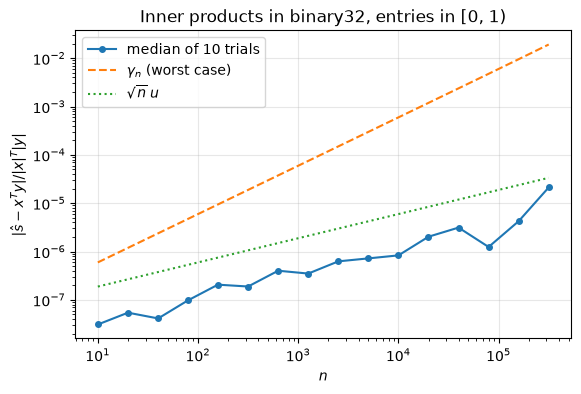

In [22]:
ns_ip = np.unique(np.round(np.logspace(1, 5.5, 16)).astype(int))
ratios = []
for trial in range(10):
    x = rng.random(ns_ip[-1], dtype=np.float32)
    y = rng.random(ns_ip[-1], dtype=np.float32)
    p64 = x.astype(np.float64) * y.astype(np.float64)
    ref, absref = np.cumsum(p64)[ns_ip - 1], np.cumsum(np.abs(p64))[ns_ip - 1]
    comp = np.cumsum(x * y)[ns_ip - 1].astype(np.float64)         # binary32, recursive
    ratios.append(np.abs(comp - ref) / absref)
ratios = np.array(ratios)
assert np.all(ratios <= np.array([gamma(n, u32) for n in ns_ip]))
fig, ax = plt.subplots()
ax.loglog(ns_ip, np.median(ratios, axis=0), "o-", ms=4, label="median of 10 trials")
ax.loglog(ns_ip, [gamma(n, u32) for n in ns_ip], "--", label=r"$\gamma_n$ (worst case)")
ax.loglog(ns_ip, np.sqrt(ns_ip) * u32, ":", label=r"$\sqrt{n}\,u$")
ax.set_xlabel("$n$")
ax.set_ylabel(r"$|\hat s - x^Ty| / |x|^T|y|$")
ax.set_title("Inner products in binary32, entries in [0, 1)")
ax.legend()
plt.show()

The median error follows $\sqrt n\,u$ over most of the range and stays far
below $\gamma_n$. As in [Figure 3.4](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-fig-inner-products), for the largest
$n$ it may begin to grow faster than $\sqrt n\,u$, because many terms become
small compared with the spacing of the partial sums and are rounded in a
systematic direction; the probabilistic model is an assumption, while
$\gamma_n$ is a guarantee.

**Matrix products.** By [Corollary 3.1](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-cor-matmul),
$|\widehat C - AB|\le\gamma_n|A||B|$ entrywise, whatever order the BLAS uses.
For binary32 inputs, the binary64 product $C_{64}$ is within
$\gamma_n^{(64)}|A||B|$ of the exact product, so the binary32 result must
satisfy $|\widehat C_{32} - C_{64}|\le(\gamma_n^{(32)}+\gamma_n^{(64)})|A||B|$.
This is exactly the kind of tolerance used in Lab 1.

In [23]:
m, n, p = 200, 500, 150
A = rng.standard_normal((m, n)).astype(np.float32)
B = rng.standard_normal((n, p)).astype(np.float32)
C32 = (A @ B).astype(np.float64)
C64 = A.astype(np.float64) @ B.astype(np.float64)
absAB = np.abs(A.astype(np.float64)) @ np.abs(B.astype(np.float64))
ratio = np.abs(C32 - C64) / absAB
print(f"max |C32 - C64| / (|A||B|) = {ratio.max():.2e};  gamma_n(binary32) = {gamma(n, u32):.2e}")
assert np.all(np.abs(C32 - C64) <= (gamma(n, u32) + gamma(n)) * absAB)

max |C32 - C64| / (|A||B|) = 1.52e-07;  gamma_n(binary32) = 2.98e-05


## 8. Cancellation

**The decimal example** ([Example 3.4](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-exa-cancel-decimal)). Python's
`decimal` module can emulate four-digit decimal arithmetic with round to
nearest, ties to even.

In [24]:
with localcontext() as ctx:
    ctx.prec, ctx.rounding = 4, ROUND_HALF_EVEN
    r1, r0 = Decimal(1001).sqrt(), Decimal(1000).sqrt()
    naive4, stable4 = r1 - r0, 1 / (r1 + r0)
with localcontext() as ctx:
    ctx.prec = 30
    true = Decimal(1001).sqrt() - Decimal(1000).sqrt()
    print(f"sqrt(1001) -> {r1}, sqrt(1000) -> {r0};  naive {naive4}, rewritten {stable4}, true {true:.10f}")
    print(f"relative errors: naive {abs(naive4 - true) / true:.3f}, rewritten {abs(stable4 - true) / true:.2e}  (u = 5e-4)")
    assert abs(stable4 - true) / true < Decimal("5e-4")

sqrt(1001) -> 31.64, sqrt(1000) -> 31.62;  naive 0.02, rewritten 0.01581, true 0.0158074374
relative errors: naive 0.265, rewritten 1.62e-4  (u = 5e-4)


**The same in binary64.** We compare $\sqrt{x+1}-\sqrt x$ with
$1/(\sqrt{x+1}+\sqrt x)$ against a 50-digit decimal reference and check the
first-order bounds derived in the notes: at most about $5(x+1)u$ for the
naive formula and $\tfrac72u$ for the rewritten one.

In [25]:
def ref_sqrtdiff(x):
    with localcontext() as ctx:
        ctx.prec = 50
        return 1 / ((Decimal(x) + 1).sqrt() + Decimal(x).sqrt())


def rel_err_dec(computed, ref):
    with localcontext() as ctx:
        ctx.prec = 50
        return float(abs((Decimal(computed) - ref) / ref))


for x in [1e4, 1e8, 1e12, 1e14, 1e16]:
    naive = math.sqrt(x + 1) - math.sqrt(x)
    stable = 1 / (math.sqrt(x + 1) + math.sqrt(x))
    ref = ref_sqrtdiff(x)
    en, es = rel_err_dec(naive, ref), rel_err_dec(stable, ref)
    print(f"x = {x:7.0e}: naive {naive:.6e} (rel. error {en:.1e}),  rewritten {stable:.6e} (rel. error {es:.1e})")
    assert es <= 3.5 * u * 1.01                        # first-order bound 7u/2
    assert en <= 5 * (x + 1) * u * 1.01 or en == 1.0   # first-order bound (capped at 1)

x =   1e+04: naive 4.999875e-03 (rel. error 2.1e-13),  rewritten 4.999875e-03 (rel. error 1.7e-17)
x =   1e+08: naive 5.000000e-05 (rel. error 1.4e-08),  rewritten 5.000000e-05 (rel. error 9.0e-17)
x =   1e+12: naive 5.000038e-07 (rel. error 7.6e-06),  rewritten 5.000000e-07 (rel. error 1.3e-16)
x =   1e+14: naive 5.029142e-08 (rel. error 5.8e-03),  rewritten 5.000000e-08 (rel. error 6.0e-17)
x =   1e+16: naive 0.000000e+00 (rel. error 1.0e+00),  rewritten 5.000000e-09 (rel. error 4.6e-17)


At $x = 10^{14}$ the naive formula has only two or three correct digits; the
two square roots do *not* round to the same number (they differ by about 27
units in the last place), but their difference is dominated by their
rounding errors. For $x\ge2^{54}\approx 1.8\times10^{16}$ the spacing is at
least $4$, so $\operatorname{fl}(x+1) = x$ and the naive result is $0$. In
$[2^{53},2^{54})$ the spacing is $2$ and $x+1$ is a tie, which rounds to $x$
only when the last significand bit of $x$ is even, as for $x = 10^{16}$
above; for $x = 2^{53}+2$ it rounds up to $x+2$.

**The quadratic formula** ([Algorithm 3.4](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-alg-quadratic)).

In [26]:
def roots_textbook(a, b, c):
    d = math.sqrt(b * b - 4 * a * c)
    return (-b + d) / (2 * a), (-b - d) / (2 * a)


def roots_stable(a, b, c):
    d = math.sqrt(b * b - 4 * a * c)
    q = -0.5 * (b + math.copysign(d, b) if b != 0 else d)
    return q / a, c / q


with localcontext() as ctx:
    ctx.prec = 50
    small_exact = (Decimal(10) ** 8 - (Decimal(10) ** 16 - 4).sqrt()) / 2
tb = min(roots_textbook(1.0, -1e8, 1.0))
st = min(roots_stable(1.0, -1e8, 1.0))
print(f"small root: textbook {tb!r} (rel. error {rel_err_dec(tb, small_exact):.3f}), "
      f"stable {st!r} (rel. error {rel_err_dec(st, small_exact):.1e})")
assert rel_err_dec(st, small_exact) <= 4 * u

small root: textbook 7.450580596923828e-09 (rel. error 0.255), stable 1e-08 (rel. error 7.9e-17)


**Logarithms and exponentials near zero.** `np.log(1 + x)` computes the
logarithm of $\operatorname{fl}(1+x)$, which has already lost the low-order digits of
$x$; `np.log1p` and `np.expm1` avoid forming $1+x$.

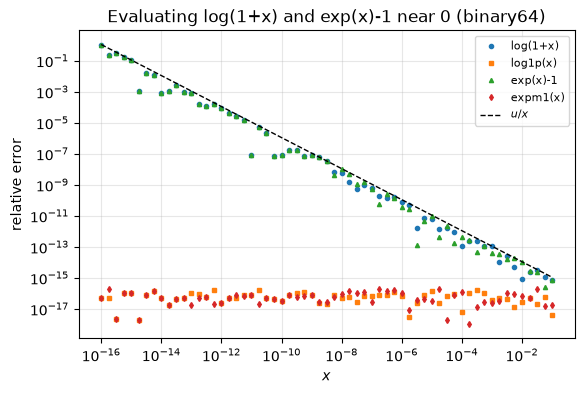

x = 1e-15: log(1+x) = np.float64(1.110223024625156e-15), log1p(x) = np.float64(9.999999999999997e-16)
max rel. error: log1p 1.47 u, expm1 1.83 u


In [27]:
xs = np.logspace(-16, -1, 61)
errs = {"log(1+x)": [], "log1p(x)": [], "exp(x)-1": [], "expm1(x)": []}
with localcontext() as ctx:
    ctx.prec = 50
    for x in xs:
        lref, eref = (1 + Decimal(x)).ln(), Decimal(x).exp() - 1
        errs["log(1+x)"].append(rel_err_dec(np.log(1 + x), lref))
        errs["log1p(x)"].append(rel_err_dec(np.log1p(x), lref))
        errs["exp(x)-1"].append(rel_err_dec(np.exp(x) - 1, eref))
        errs["expm1(x)"].append(rel_err_dec(np.expm1(x), eref))
fig, ax = plt.subplots()
for name, mk in zip(errs, ["o", "s", "^", "d"]):
    ax.loglog(xs, np.maximum(errs[name], 1e-18), mk, ms=3, label=name)
ax.loglog(xs, u / xs, "k--", lw=1, label=r"$u/x$")
ax.set_xlabel("$x$")
ax.set_ylabel("relative error")
ax.set_title("Evaluating log(1+x) and exp(x)-1 near 0 (binary64)")
ax.legend(fontsize=8)
plt.show()
print(f"x = 1e-15: log(1+x) = {np.log(1 + 1e-15)!r}, log1p(x) = {np.log1p(1e-15)!r}")
print(f"max rel. error: log1p {max(errs['log1p(x)']) / u:.2f} u, expm1 {max(errs['expm1(x)']) / u:.2f} u")
assert max(errs["log1p(x)"]) < 4 * u and max(errs["expm1(x)"]) < 4 * u    # observed accuracy of the library

The naive errors lie on or below the line $u/x$: the rounding error of
$\operatorname{fl}(1+x)$ is at most $u$ in absolute terms, which is a relative error of
up to $u/x$ in the quantity $x$ that the logarithm then sees. The library
functions stay within a few $u$ over the whole range.

**The sample variance.** For the four numbers $10^8 + (4, 7, 13, 16)$, whose
exact sample variance is $30$, the one-pass formula
$(\sum x_i^2 - n\bar x^2)/(n-1)$ fails while the two-pass formula does not.

In [28]:
def var_two_pass(x):
    x = np.asarray(x)
    m = np.sum(x) / len(x)
    return np.sum((x - m) ** 2) / (len(x) - 1)


def var_one_pass(x):
    x = np.asarray(x)
    n = len(x)
    m = np.sum(x) / n
    return (np.sum(x * x) - n * m * m) / (n - 1)


def var_exact(x):
    xf = [Fraction(v) for v in x]
    m = sum(xf) / len(xf)
    return sum((v - m) ** 2 for v in xf) / (len(xf) - 1)


for shift in (0.0, 1e4, 1e8, 1e9):
    data = [shift + v for v in (4.0, 7.0, 13.0, 16.0)]
    print(f"shift {shift:7.0e}: exact {float(var_exact(data)):5.1f}, two-pass {var_two_pass(data):8.4f}, "
          f"one-pass {var_one_pass(data):8.4f}")
assert var_exact([1e8 + v for v in (4.0, 7.0, 13.0, 16.0)]) == 30

shift   0e+00: exact  30.0, two-pass  30.0000, one-pass  30.0000
shift   1e+04: exact  30.0, two-pass  30.0000, one-pass  30.0000
shift   1e+08: exact  30.0, two-pass  30.0000, one-pass  29.3333
shift   1e+09: exact  30.0, two-pass  30.0000, one-pass -170.6667


The data are exactly representable, so the whole loss is due to the
cancellation between $\sum x_i^2\approx4\times10^{16}$ (for the shift
$10^8$) and $n\bar x^2$, both of which are rounded before they are
subtracted. For the shift $10^9$ the one-pass formula even returns a
*negative* variance.

## 9. Overflow, underflow and scaling

The naive 2-norm $\sqrt{\sum x_i^2}$ overflows or underflows in its
intermediate squares. [Algorithm 3.5](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-alg-scaled-norm) divides by the largest
entry first.

In [29]:
def norm_naive(x):
    return math.sqrt(sum(v * v for v in x))


def norm_scaled(x):
    M = max(abs(v) for v in x)
    if M == 0:
        return 0.0
    return M * math.sqrt(math.fsum((v / M) ** 2 for v in x))


tests = {"(1e200, 1e200)": [1e200, 1e200], "(3e-200, 4e-200)": [3e-200, 4e-200], "(3, 4)": [3.0, 4.0]}
for name, x in tests.items():
    with np.errstate(over="ignore", under="ignore"):          # np.linalg.norm overflows/underflows here
        vals = {"naive": norm_naive(x), "scaled": norm_scaled(x), "np.hypot": float(np.hypot(*x)),
                "np.linalg.norm": float(np.linalg.norm(x)), "scipy.linalg.norm": float(sla.norm(x))}
    print(f"{name:>17s}: " + ",  ".join(f"{k} {v:.6e}" for k, v in vals.items()))
    exact = math.hypot(*x)
    assert abs(vals["scaled"] - exact) <= 6 * u * exact      # a few roundings: two quotients, squares, sqrt, product

   (1e200, 1e200): naive inf,  scaled 1.414214e+200,  np.hypot 1.414214e+200,  np.linalg.norm inf,  scipy.linalg.norm 1.414214e+200
 (3e-200, 4e-200): naive 0.000000e+00,  scaled 5.000000e-200,  np.hypot 5.000000e-200,  np.linalg.norm 0.000000e+00,  scipy.linalg.norm 5.000000e-200
           (3, 4): naive 5.000000e+00,  scaled 5.000000e+00,  np.hypot 5.000000e+00,  np.linalg.norm 5.000000e+00,  scipy.linalg.norm 5.000000e+00


The naive formula returns `inf` for $(10^{200},10^{200})$ and $0$ for
$(3\times10^{-200},4\times10^{-200})$; the scaled algorithm, `np.hypot` and
`scipy.linalg.norm` (which calls the BLAS routine `nrm2`) return the correct
values. In NumPy 2.x, the version used when this book was written,
`np.linalg.norm` evaluates the vector 2-norm as $\sqrt{x^Tx}$ without
scaling and fails in the same way as the naive formula; check the line
above for the version that executed this notebook.

## 10. Single and half precision

Every statement of the chapter holds in other formats with the appropriate
$u$. In binary32, $u = 2^{-24}$ and $1 + 2^{-24}$ rounds to $1$; in binary16,
the spacing in $[2048, 4096)$ is $2$, so $2048 + 1 = 2048$, and the
worst-case constant $\gamma_n$ exists only for $n < 2048$.

In [30]:
one32 = np.float32(1)
print("binary32: 1 + 2^-24 == 1:", one32 + np.float32(2.0**-24) == one32,
      "   1 + 2^-23 > 1:", one32 + np.float32(2.0**-23) > one32)
print("binary16: 2048 + 1 =", np.float16(2048) + np.float16(1), "   spacing at 2048:", np.spacing(np.float16(2048)))
x = rng.standard_normal(10_000)                       # binary64 data, rounded to lower precision
for t in (np.float16, np.float32):
    xt = x.astype(t)
    rel = np.abs(xt.astype(np.float64) - x) / np.abs(x)
    ut = 2.0 ** -(np.finfo(t).nmant + 1)
    finite_normal = np.abs(x) >= float(np.finfo(t).tiny)
    print(f"{t.__name__:>8s}: max relative rounding error of the data {rel[finite_normal].max() / ut:.4f} u")
    assert rel[finite_normal].max() <= ut

binary32: 1 + 2^-24 == 1: True    1 + 2^-23 > 1: True
binary16: 2048 + 1 = 2.048e+03    spacing at 2048: 2.0
 float16: max relative rounding error of the data 0.9969 u
 float32: max relative rounding error of the data 0.9851 u


## Common mistakes

- Using `np.finfo(float).eps` as the bound on relative rounding errors and
  then claiming the result is sharp. The sharp bound is $u = \epsilon_{\mathrm{mach}}/2$.
- Believing that $\operatorname{fl}(x) = x(1+\delta)$, $|\delta|\le u$ holds for all $x$.
  It fails in the subnormal range (Section 3).
- Measuring errors against a reference that is no more accurate than the
  computation. Use `fractions.Fraction`, `math.fsum`, or `decimal` with
  enough digits.
- Using Python's built-in `sum` to demonstrate recursive summation; since
  Python 3.12 it is compensated.
- Expecting compensated summation to fix an ill-conditioned sum.
- Blaming the subtraction for cancellation: the subtraction is exact; the
  error was already in its operands.
- Computing $\sqrt{a^2+b^2}$, $\sqrt{x^Tx}$ or $\log\sum e^{x_i}$ without
  scaling.
- Comparing floats with `==` after arithmetic, as in `0.1 + 0.2 == 0.3`.

## Your turn

1. Sum the harmonic series in binary32 until the partial sum stops changing
   ([Exercise 3.11](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-ex-harmonic)). Use `np.cumsum` on a float32 array of the
   terms, which adds sequentially. Explain the value of $k$ you find.
2. Implement Welford's one-pass variance ([Exercise 3.9](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-ex-variance)) and add
   it to the comparison of Section 8 for data $\mu + z_i$, $\mu = 10^k$.
3. Implement `logsumexp` with the shift by $\max_i x_i$
   ([Exercise 3.10](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03-ex-logsumexp)) and test it on $(1000, 1000)$ and
   $(-1000, -1000)$.
4. Construct data for which recursive summation attains the bound
   $\gamma_{n-1}\sum|x_i|$ to within a factor of $2$ for $n = 10, 100, 1000$.
5. Repeat the summation experiment of Section 6 in binary64, using
   `math.fsum` as the reference.

## Key takeaways

- Binary64 has 52 stored fraction bits and 53 bits of precision thanks to
  the hidden bit; its numbers are spaced with relative spacing in
  $(u, 2u]$.
- In the normal range, $\operatorname{fl}(x) = x(1+\delta)$ with $|\delta|\le u = 2^{-53}$;
  machine epsilon $\epsilon_{\mathrm{mach}} = 2^{-52}$ is the gap from $1$ to the next
  float, and `1 + 2**-53 == 1`.
- The standard model and the $\gamma_n$ lemma give rigorous bounds; measured
  errors are usually much smaller than the bounds, but never larger.
- The relative error of every summation method is proportional to
  $\kappa_\Sigma$; pairwise and compensated summation reduce the dependence
  on $n$, not on the conditioning.
- Cancellation reveals earlier errors; reformulate, use `log1p`/`expm1`, and
  scale to avoid overflow and underflow.

## Further reading

Higham (2002), Chapters 1--4, for everything in this lab;
Goldberg (1991) for IEEE arithmetic and compensated summation;
Overton (2001) for a short introduction to the IEEE standard; and
Higham and Mary (2019) for probabilistic rounding error analysis.